# Multivariate Regression Epidemics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
cwd = os.getcwd()
print(cwd)

c:\Users\danie\Documents\GitHub\thesis\modelling


In [3]:
df = pd.read_csv('../Data/gold/epidemics.csv')
df.head()

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,...,google_pharmacy,google_symptom,co,dew,humidity,no2,o3,pm10,pm25,so2
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,...,6,44,6.007143,11.964286,82.078571,7.164286,18.142857,48.857143,118.285714,0.742857
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,...,6,40,5.992857,12.285714,79.671429,6.228571,13.057143,25.214286,63.214286,0.628571
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,...,6,38,4.335714,12.678571,79.557143,4.700000,11.757143,15.214286,37.285714,0.614286
3,2020-04-13,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,...,5,31,5.028571,11.714286,82.707143,7.000000,12.092857,31.571429,74.785714,0.642857
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,...,5,29,5.207143,11.928571,83.142857,7.192857,9.607143,23.071429,53.500000,0.442857


# Wrangle

In [4]:
df.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')

In [5]:
tarteg_cols = ['dengue', 'zika', 'chik', 'var']
for col in tarteg_cols:
    df['cum_'+ col ] = np.cumsum(df[col])

In [6]:
df['cum_dengue_t_1'] = df['cum_dengue'].shift(-1)
df['cum_zika_t_1'] = df['cum_zika'].shift(-1)
df['cum_chik_t_1'] = df['cum_chik'].shift(-1)
df['cum_var_t_1'] = df['cum_var'].shift(-1)


In [7]:
print(df['cum_dengue_t_1'].isnull().sum(), 'Nans for dengue +1')
print(df['cum_zika_t_1'].isnull().sum(), 'Nans for zika + 1')
print(df['cum_chik_t_1'].isnull().sum(), 'Nans for chikungunya +1')
print(df['cum_var_t_1'].isnull().sum(), 'Nans for chickenpox +1')

1 Nans for dengue +1
1 Nans for zika + 1
1 Nans for chikungunya +1
1 Nans for chickenpox +1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              197 non-null    object 
 1   dengue            197 non-null    int64  
 2   zika              197 non-null    float64
 3   chik              197 non-null    float64
 4   var               197 non-null    float64
 5   date              197 non-null    object 
 6   tavg              197 non-null    float64
 7   tmin              197 non-null    float64
 8   tmax              197 non-null    float64
 9   prcp              197 non-null    float64
 10  wdir              197 non-null    float64
 11  wspd              197 non-null    float64
 12  pres              197 non-null    float64
 13  mob_index         197 non-null    float64
 14  google_physician  197 non-null    int64  
 15  google_hospital   197 non-null    int64  
 16  google_pharmacy   197 non-null    int64  
 1

In [9]:
# drop nans
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196 entries, 0 to 195
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              196 non-null    object 
 1   dengue            196 non-null    int64  
 2   zika              196 non-null    float64
 3   chik              196 non-null    float64
 4   var               196 non-null    float64
 5   date              196 non-null    object 
 6   tavg              196 non-null    float64
 7   tmin              196 non-null    float64
 8   tmax              196 non-null    float64
 9   prcp              196 non-null    float64
 10  wdir              196 non-null    float64
 11  wspd              196 non-null    float64
 12  pres              196 non-null    float64
 13  mob_index         196 non-null    float64
 14  google_physician  196 non-null    int64  
 15  google_hospital   196 non-null    int64  
 16  google_pharmacy   196 non-null    int64  
 17  go

In [10]:
# convert date to numeric
df['date'] = pd.to_datetime(df['date'])
df['date_numeric'] = df['date'].apply(lambda x: x.timestamp())

In [11]:
df_og = df.copy()

# Regression Framework

In [12]:
df.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'cum_dengue',
       'cum_zika', 'cum_chik', 'cum_var', 'cum_dengue_t_1', 'cum_zika_t_1',
       'cum_chik_t_1', 'cum_var_t_1', 'date_numeric'],
      dtype='object')

In [13]:
targets = ['cum_dengue_t_1', 'cum_zika_t_1', 'cum_chik_t_1', 'cum_var_t_1']

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer

In [15]:

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer


def evaluate_metrics_cv(df, targets, model, n_splits=5):

    metrics = {}

    for target_variable in targets:
        split_idx = int(len(df) * 0.8)
        # drop columns
        drop_columns = targets + ['date', 'week'] # not dropping epidemics at t because they are useful

        X = df.drop(columns=drop_columns)
        y = df[target_variable]
        
        # train-test split
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

        # mark dummies
        dummy_cols = [col for col in X.columns if set(X[col].unique()) <= {0, 1}]
        numeric_cols = [col for col in X.columns if col not in dummy_cols]
        
        # standard scaling
        scaler = StandardScaler()
        X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
        X_test_scaled_numeric = scaler.transform(X_test[numeric_cols])

        X_train_scaled = np.concatenate([X_train_scaled_numeric, X_train[dummy_cols].values], axis=1)
        X_test_scaled = np.concatenate([X_test_scaled_numeric, X_test[dummy_cols].values], axis=1)
        # cross validation
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        mse_scores = cross_val_score(model, X_train_scaled, y_train, 
                                     scoring=make_scorer(mean_squared_error), cv=kf)
        rmse_cv = np.sqrt(mse_scores).mean()

        r2_cv = cross_val_score(model, X_train_scaled, y_train, scoring='r2', cv=kf).mean()
        # model fitting
        model.fit(X_train_scaled, y_train)
        # predictions
        y_pred_test = model.predict(X_test_scaled)
        # metrics
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        r2_test = r2_score(y_test, y_pred_test)

        metrics[target_variable] = {
            'RMSE_CV': rmse_cv,
            'R2_CV': r2_cv,
            'RMSE_Test': rmse_test,
            'R2_Test': r2_test
        }
    return metrics


In [16]:
mets = evaluate_metrics_cv(df, targets, LinearRegression())
mets

{'cum_dengue_t_1': {'RMSE_CV': 86.02002819288677,
  'R2_CV': 0.9999929933014874,
  'RMSE_Test': 450.39849202560487,
  'R2_Test': 0.9996647152010097},
 'cum_zika_t_1': {'RMSE_CV': 1.1825206448210324,
  'R2_CV': 0.9991188552429972,
  'RMSE_Test': 1.3179193402771223,
  'R2_Test': 0.9699898684726105},
 'cum_chik_t_1': {'RMSE_CV': 1.266929500627308,
  'R2_CV': 0.9992708297112947,
  'RMSE_Test': 1.3858547305809445,
  'R2_Test': 0.9871512880916955},
 'cum_var_t_1': {'RMSE_CV': 42.37016223936102,
  'R2_CV': 0.9999914627915001,
  'RMSE_Test': 57.783405646329015,
  'R2_Test': 0.9999521472889167}}

In [17]:
def evaluate_models_rmse(df, targets):
    models = {
        'LinearRegression': LinearRegression(),
        'Lasso': Lasso(alpha=1.0),
        'Ridge': Ridge(alpha=1.0),
        'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
        'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'SVR': SVR(kernel='rbf')
    }

    all_metrics = []

    for model_name, model in models.items():
        metrics = evaluate_metrics_cv(df, targets, model)
        for target, scores in metrics.items():
            all_metrics.append({
                'Model': model_name,
                'Epidemic': target,
                'RMSE': scores['RMSE_Test'],
                'R2': scores['R2_Test']
            })

    metrics_df = pd.DataFrame(all_metrics)
    return metrics_df



In [18]:
df_metrics_all = evaluate_models_rmse(df,targets)
df_metrics_all

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.526e+06, tolerance: 2.776e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.736e+06, tolerance: 2.676e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

,Model,Epidemic,RMSE,R2
0,LinearRegression,cum_dengue_t_1,450.398492,0.999665
1,LinearRegression,cum_zika_t_1,1.317919,0.969990
2,LinearRegression,cum_chik_t_1,1.385855,0.987151
3,LinearRegression,cum_var_t_1,57.783406,0.999952
4,Lasso,cum_dengue_t_1,937.952548,0.998546
5,Lasso,cum_zika_t_1,1.555549,0.958192
6,Lasso,cum_chik_t_1,1.312819,0.988470
7,Lasso,cum_var_t_1,2231.326772,0.928645
8,Ridge,cum_dengue_t_1,14177.064491,0.667805
9,Ridge,cum_zika_t_1,9.215448,-0.467314


In [19]:
df_rmse_pivot = df_metrics_all.pivot(index = 'Epidemic', columns='Model', values='RMSE').reset_index()
df_rmse_pivot

Model,Epidemic,ElasticNet,GradientBoosting,Lasso,LinearRegression,RandomForest,Ridge,SVR
0,cum_chik_t_1,6.500039,23.705583,1.312819,1.385855,24.441411,9.393939,109.669701
1,cum_dengue_t_1,28631.619246,45811.162888,937.952548,450.398492,47791.344292,14177.064491,121112.837029
2,cum_var_t_1,7253.751071,16866.313760,2231.326772,57.783406,17332.664193,928.311802,48213.643342
3,cum_zika_t_1,11.312836,11.884532,1.555549,1.317919,12.516600,9.215448,70.252652


In [20]:
df_r2_pivot = df_metrics_all.pivot(index = 'Epidemic', columns='Model', values='R2').reset_index()
df_r2_pivot

Model,Epidemic,ElasticNet,GradientBoosting,Lasso,LinearRegression,RandomForest,Ridge,SVR
0,cum_chik_t_1,0.717345,-2.759460,0.988470,0.987151,-2.996471,0.409636,-79.463235
1,cum_dengue_t_1,-0.354914,-2.468667,0.998546,0.999665,-2.775013,0.667805,-23.243782
2,cum_var_t_1,0.245906,-3.076999,0.928645,0.999952,-3.305573,0.987649,-32.315028
3,cum_zika_t_1,-1.211226,-1.440363,0.958192,0.969990,-1.706842,-0.467314,-84.273813


# Explanatory variables

In [21]:
df.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'cum_dengue',
       'cum_zika', 'cum_chik', 'cum_var', 'cum_dengue_t_1', 'cum_zika_t_1',
       'cum_chik_t_1', 'cum_var_t_1', 'date_numeric'],
      dtype='object')

In [22]:
# plot only forecast (test)
def plot_predictions_cv_forecast(df, targets, model, n_splits=5):

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()

    for idx, target in enumerate(targets):
        

        split_idx = int(len(df) * 0.8)

        drop_columns = targets + ['date', 'week']

        X = df.drop(columns=drop_columns)
        y = df[target]
        
        # train-test split
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

        # mark dummies
        dummy_cols = [col for col in X.columns if set(X[col].unique()) <= {0, 1}]
        numeric_cols = [col for col in X.columns if col not in dummy_cols]
        
        # standard scaling
        scaler = StandardScaler()
        X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
        X_test_scaled_numeric = scaler.transform(X_test[numeric_cols])

        X_train_scaled = np.concatenate([X_train_scaled_numeric, X_train[dummy_cols].values], axis=1)
        X_test_scaled = np.concatenate([X_test_scaled_numeric, X_test[dummy_cols].values], axis=1)
        # cross validation
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        mse_scores = cross_val_score(model, X_train_scaled, y_train, 
                                     scoring=make_scorer(mean_squared_error), cv=kf)
        rmse_cv = np.sqrt(mse_scores).mean()

        r2_cv = cross_val_score(model, X_train_scaled, y_train, scoring='r2', cv=kf).mean()
        # model fitting
        model.fit(X_train_scaled, y_train)
        # predictions
        y_pred_test = model.predict(X_test_scaled)

        axes[idx].plot(df['date'].iloc[split_idx:], y_test, label='Actual', color='blue')
        axes[idx].plot(df['date'].iloc[split_idx:], y_pred_test, label='Predicted', color='red', linestyle='--')

        axes[idx].set_title(f'{target}', fontsize=14)
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel(target)
        axes[idx].legend()

    if len(targets) < len(axes):
        for ax in axes[len(targets):]:
            fig.delaxes(ax)

    plt.tight_layout()
    plt.show()


# Plots
All Models

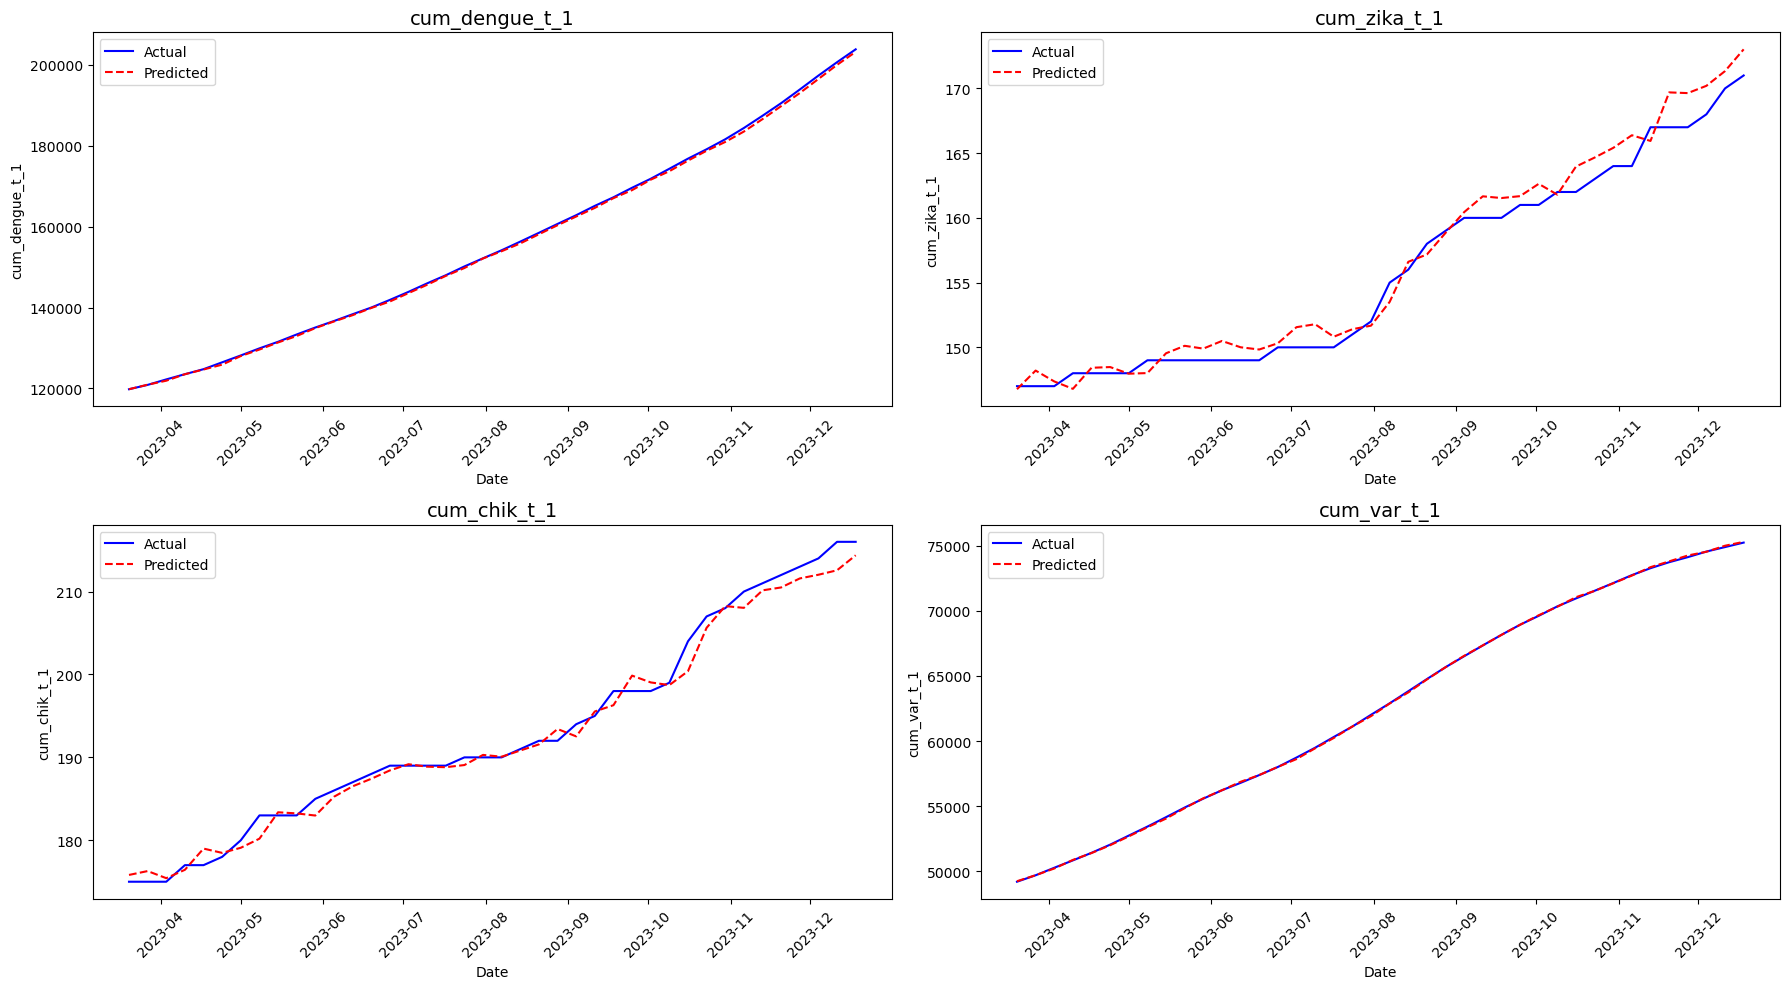

In [23]:
# Linear regression
plot_predictions_cv_forecast(df, targets, LinearRegression(), n_splits=5)

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.526e+06, tolerance: 2.776e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.736e+06, tolerance: 2.676e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

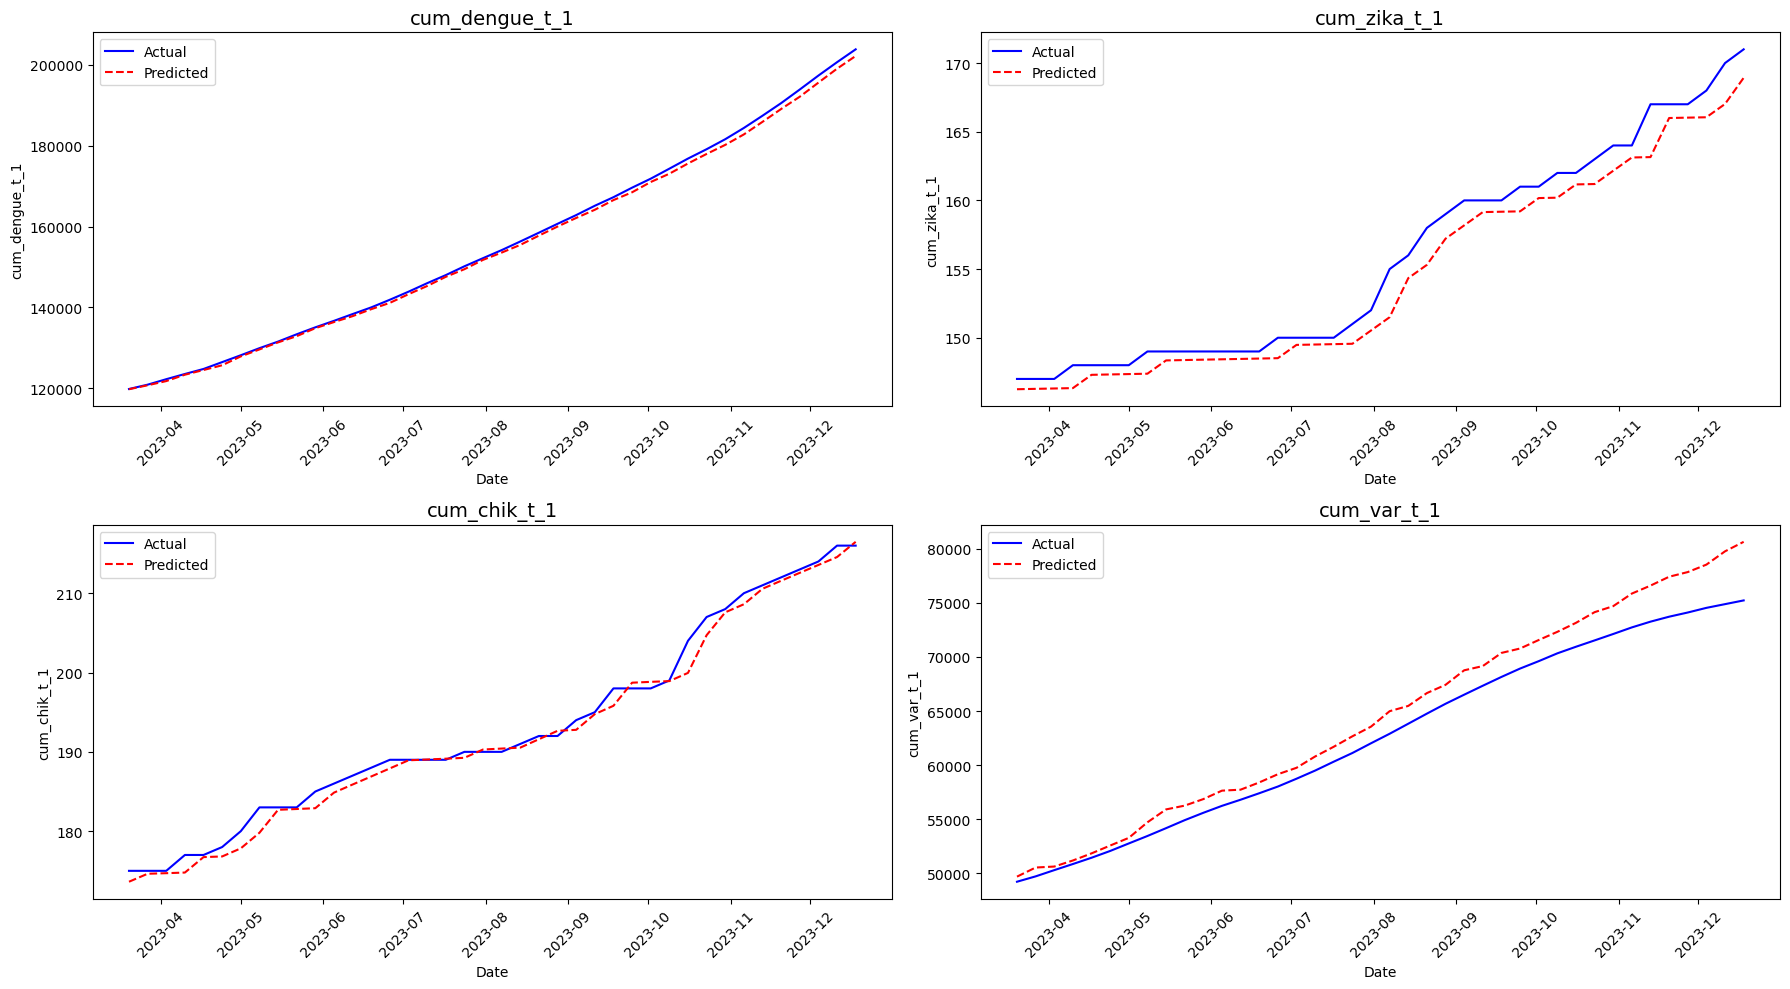

In [24]:
# Lasso
plot_predictions_cv_forecast(df, targets, Lasso(), n_splits=5)

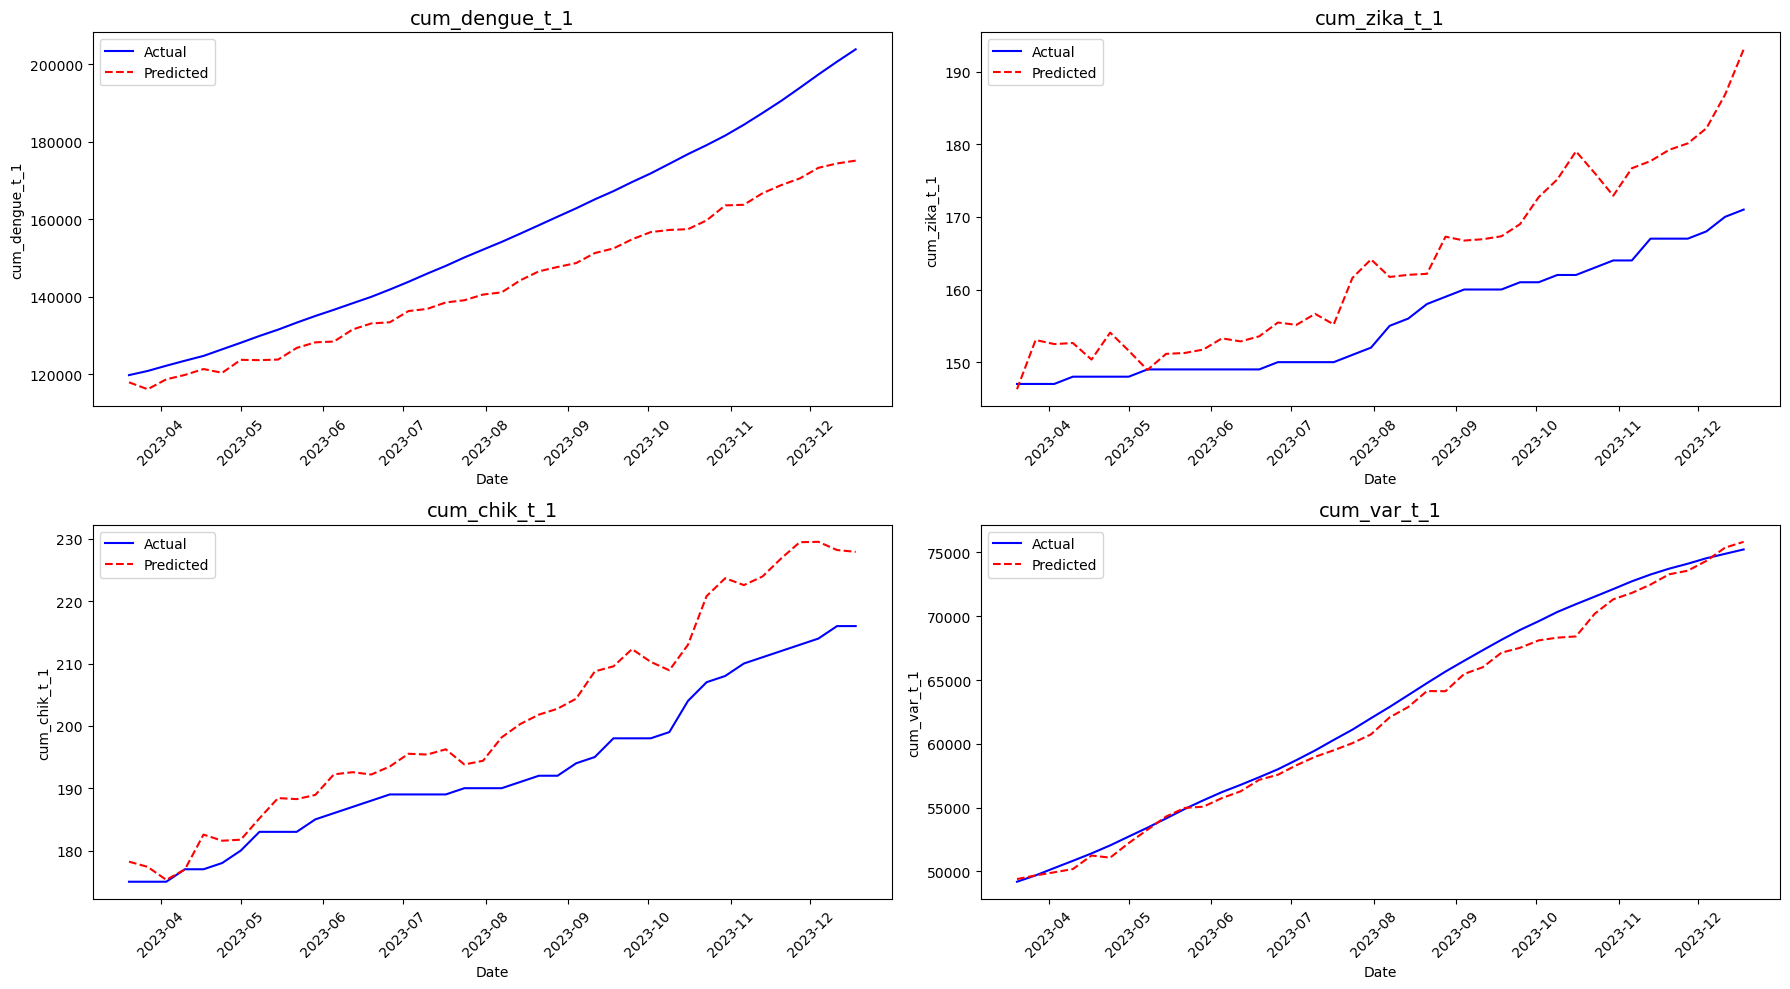

In [25]:
# Ridge
plot_predictions_cv_forecast(df, targets, Ridge(), n_splits=5)

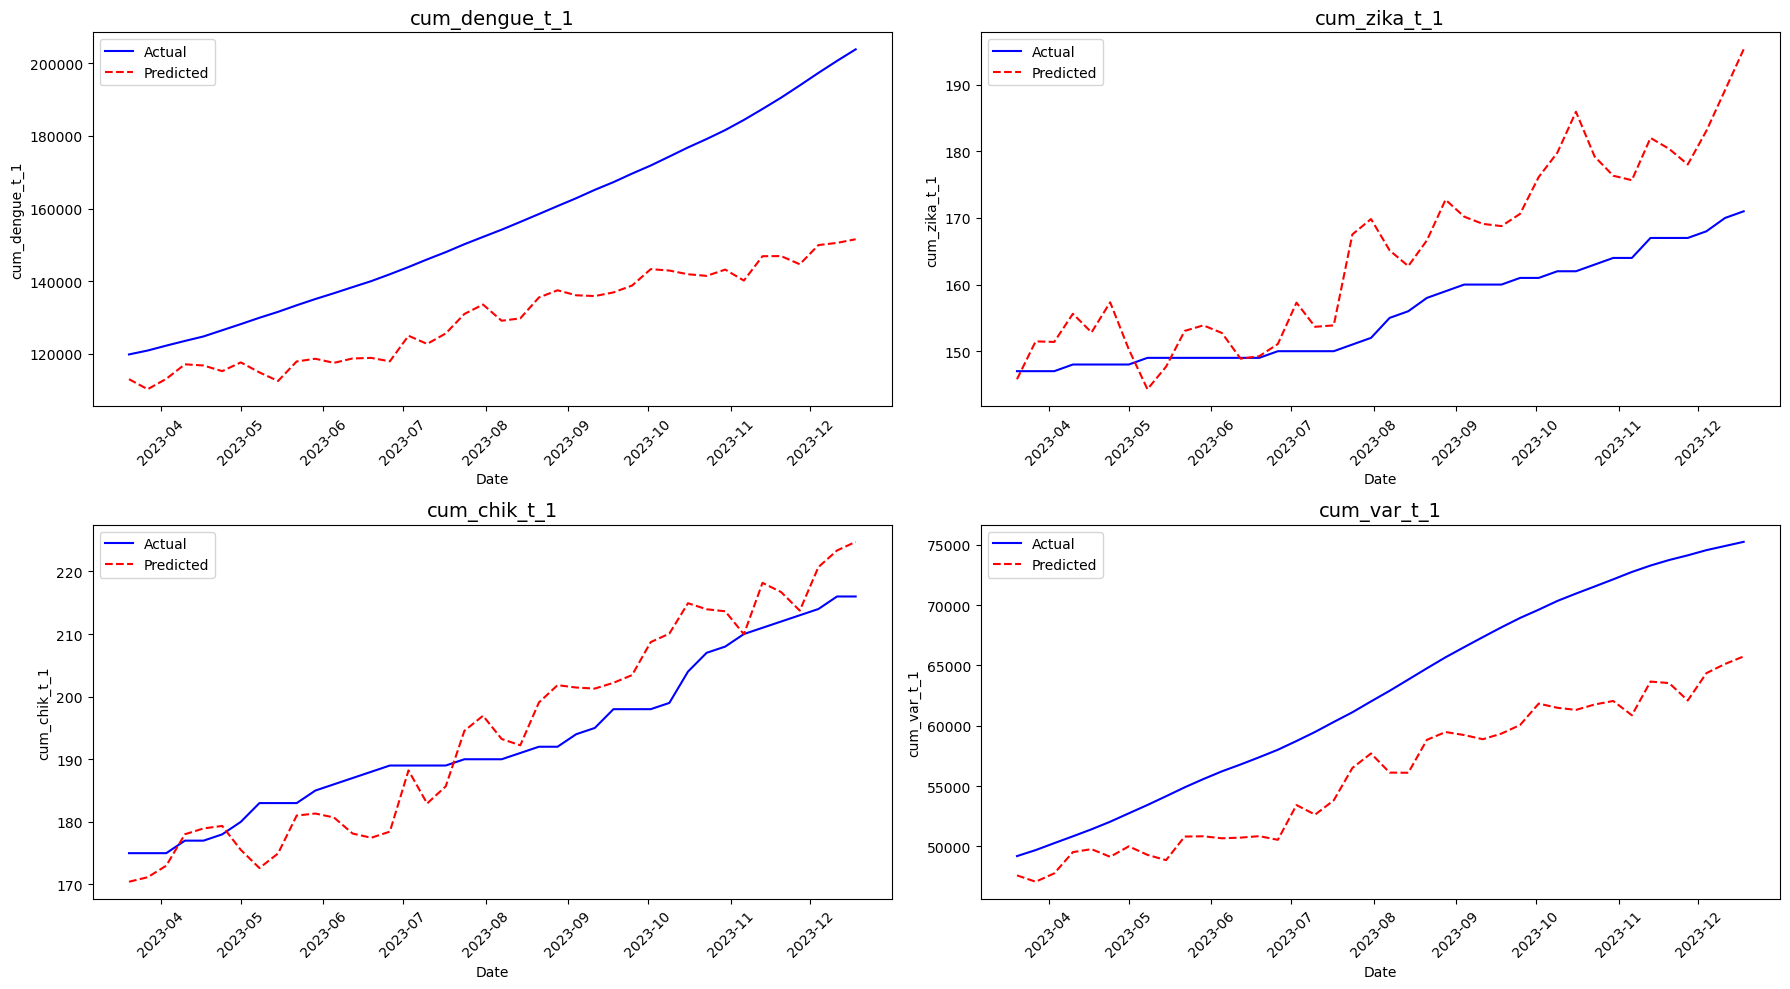

In [26]:
# ElasticNet
plot_predictions_cv_forecast(df, targets, ElasticNet(alpha = 1, l1_ratio=0.5), n_splits=5)

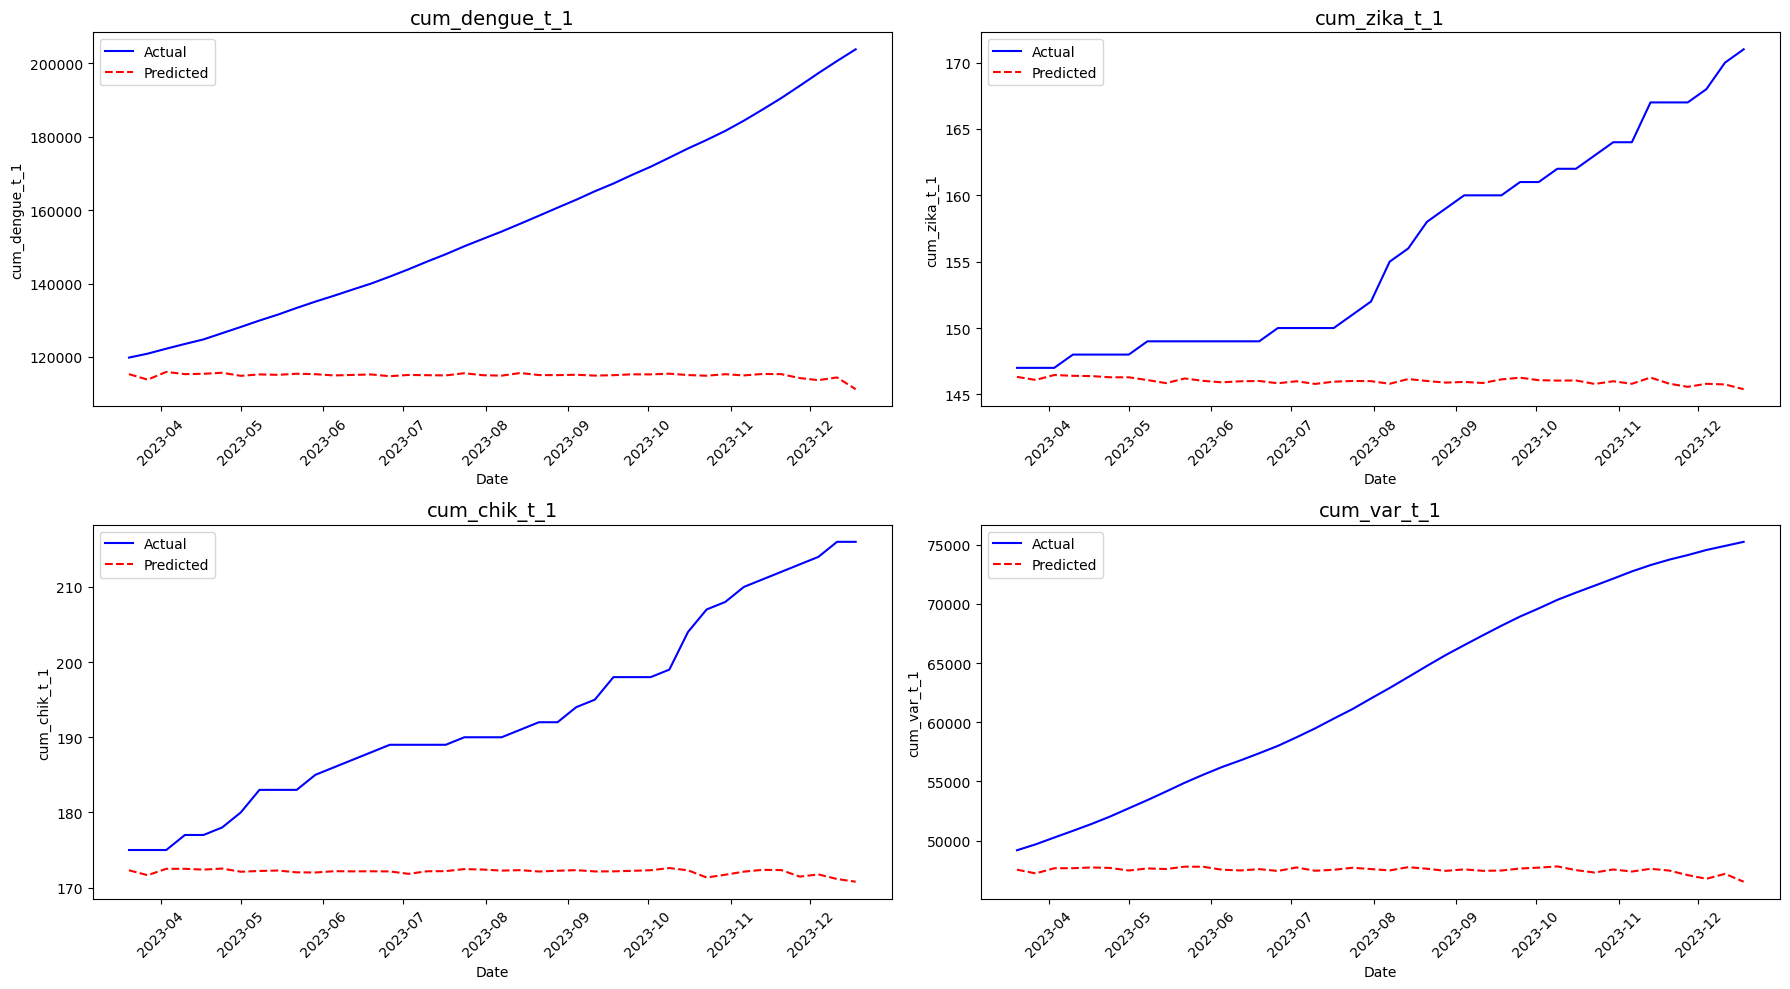

In [27]:
# RF
plot_predictions_cv_forecast(df, targets, RandomForestRegressor(n_estimators=100, random_state=42), n_splits=5)

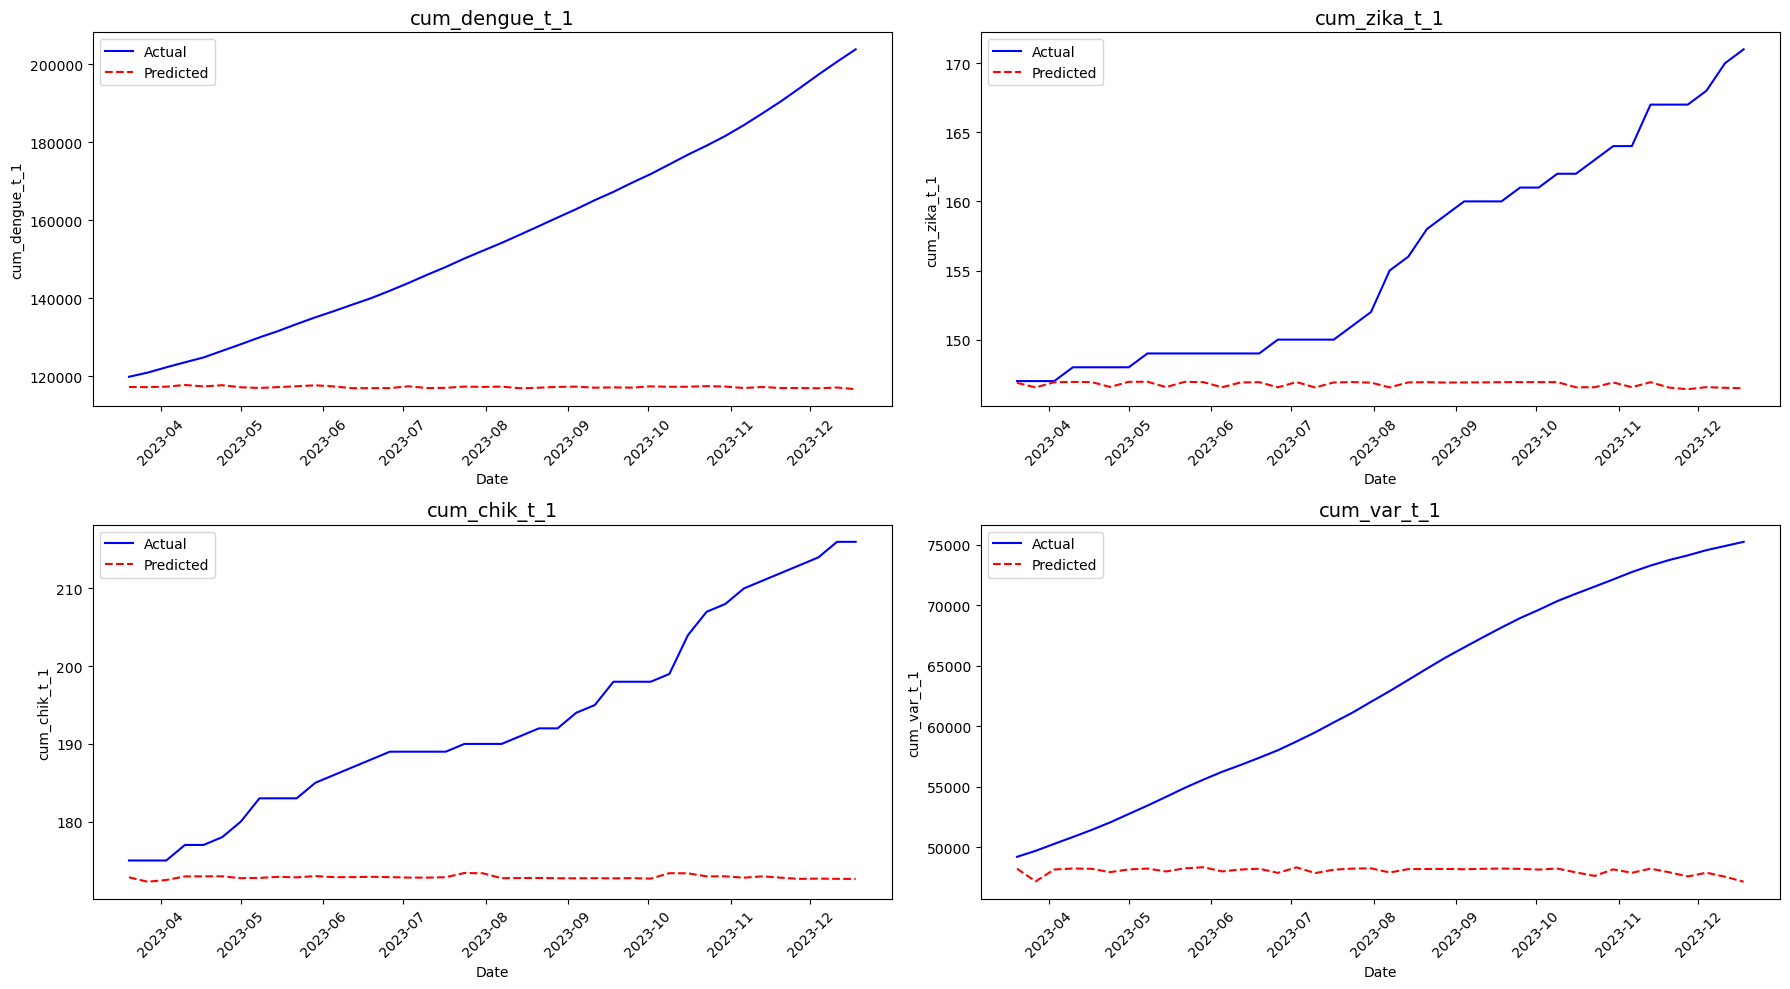

In [28]:
# Gradient Boosting
plot_predictions_cv_forecast(df, targets, GradientBoostingRegressor(n_estimators=100, random_state=42), n_splits=5)

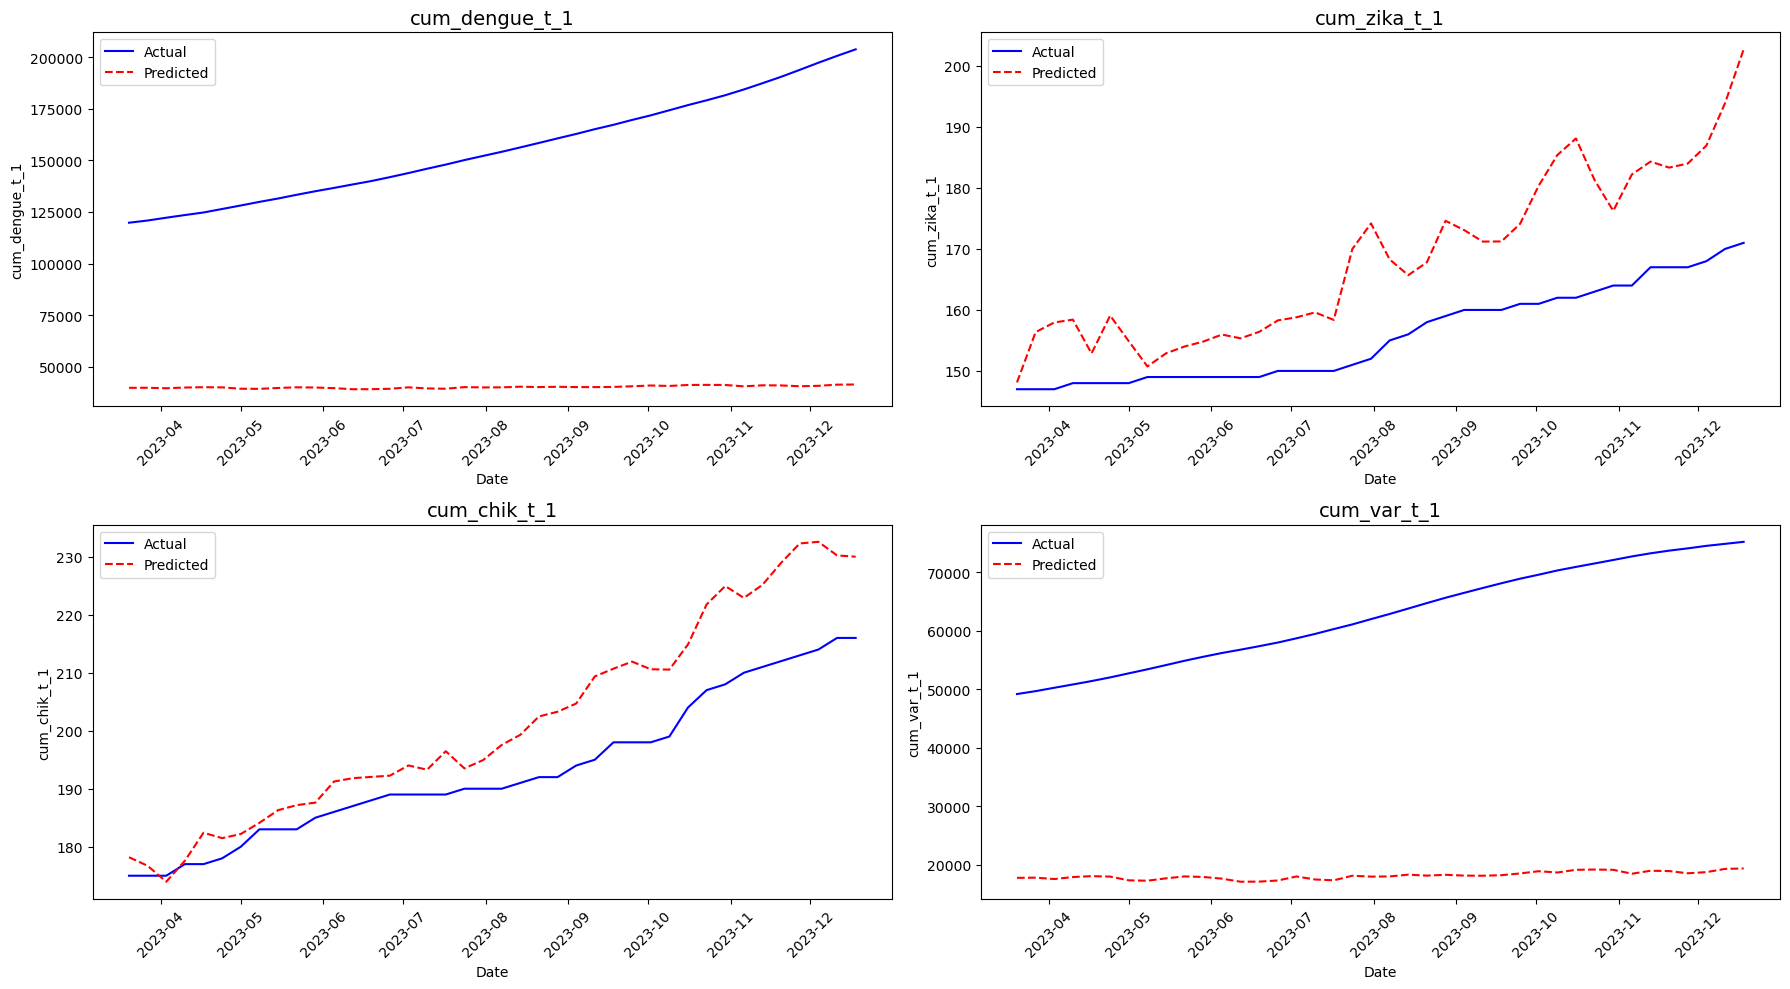

In [29]:
# SVM
plot_predictions_cv_forecast(df, targets,SVR(kernel='linear'), n_splits=5)

# Check Explainability

In [39]:
def plot_coefficients(df, targets, model):

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()

    for idx, target in enumerate(targets):

        split_idx = int(len(df) * 0.8)
        df_train = df.iloc[:split_idx]

        drop_columns = targets + ['date', 'week']

        X_train = df_train.drop(columns=drop_columns)
        y_train = df_train[target]

        dummy_cols = [col for col in X_train.columns if set(X_train[col].unique()) <= {0, 1}]
        numeric_cols = [col for col in X_train.columns if col not in dummy_cols]

        scaler = StandardScaler()
        X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
        X_train_scaled = np.concatenate([X_train_scaled_numeric, X_train[dummy_cols].values], axis=1)

        feature_names = numeric_cols + dummy_cols

        model.fit(X_train_scaled, y_train)

        if hasattr(model, 'coef_'):
            importance = model.coef_
            title = "Coefficients"
        elif hasattr(model, 'feature_importances_'):
            importance = model.feature_importances_
            title = "Feature Importances"
        else:
            raise ValueError("Model does not have coefficients or feature importances to plot.")

        # Filter non-zero coefficients/importances
        non_zero_mask = importance != 0
        filtered_importance = importance[non_zero_mask]
        filtered_features = np.array(feature_names)[non_zero_mask]

        # Sort by absolute value
        sorted_idx = np.argsort(np.abs(filtered_importance))[::-1]

        axes[idx].bar(filtered_features[sorted_idx], filtered_importance[sorted_idx])
        axes[idx].set_title(f"{target} - {title}", fontsize=14)
        axes[idx].set_xlabel("Features", fontsize=12)
        axes[idx].set_ylabel(title, fontsize=12)
        axes[idx].tick_params(axis='x', rotation=90)

    for i in range(len(targets), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()


## OLS

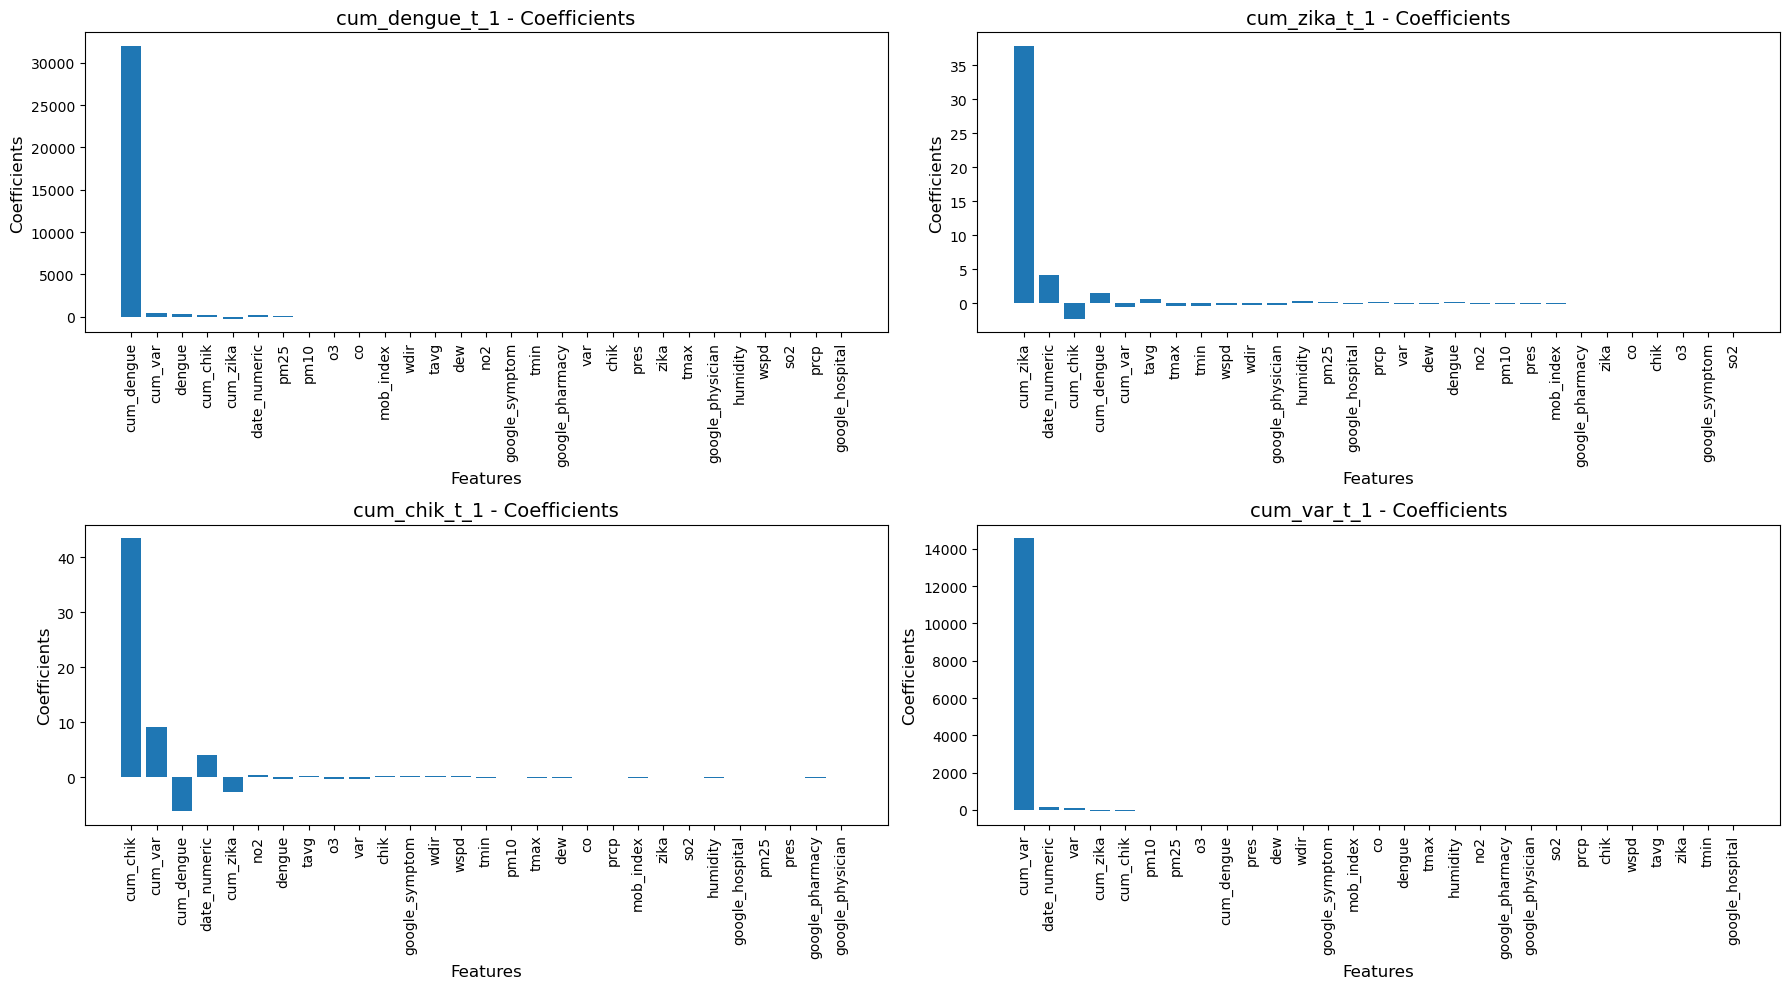

In [40]:
plot_coefficients(df, targets, LinearRegression())

## Lasso

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.926e+06, tolerance: 3.355e+06
  model = cd_fast.enet_coordinate_descent(


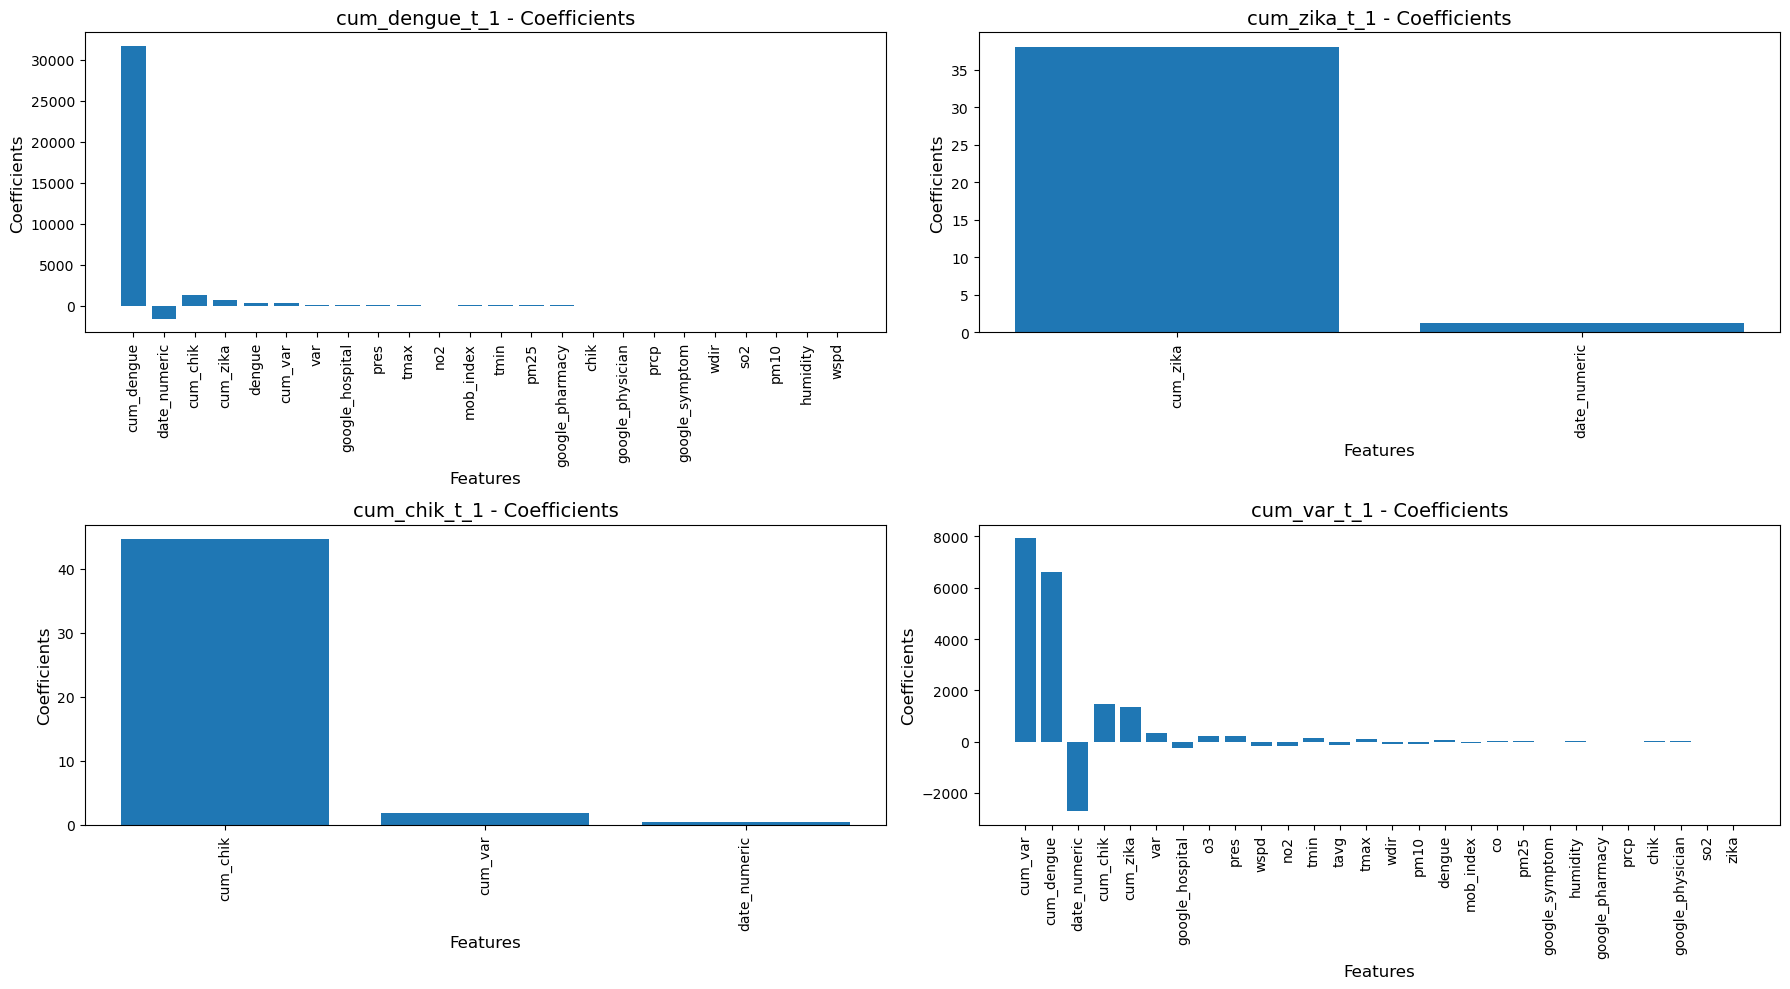

In [41]:
plot_coefficients(df, targets, Lasso())

## Ridge

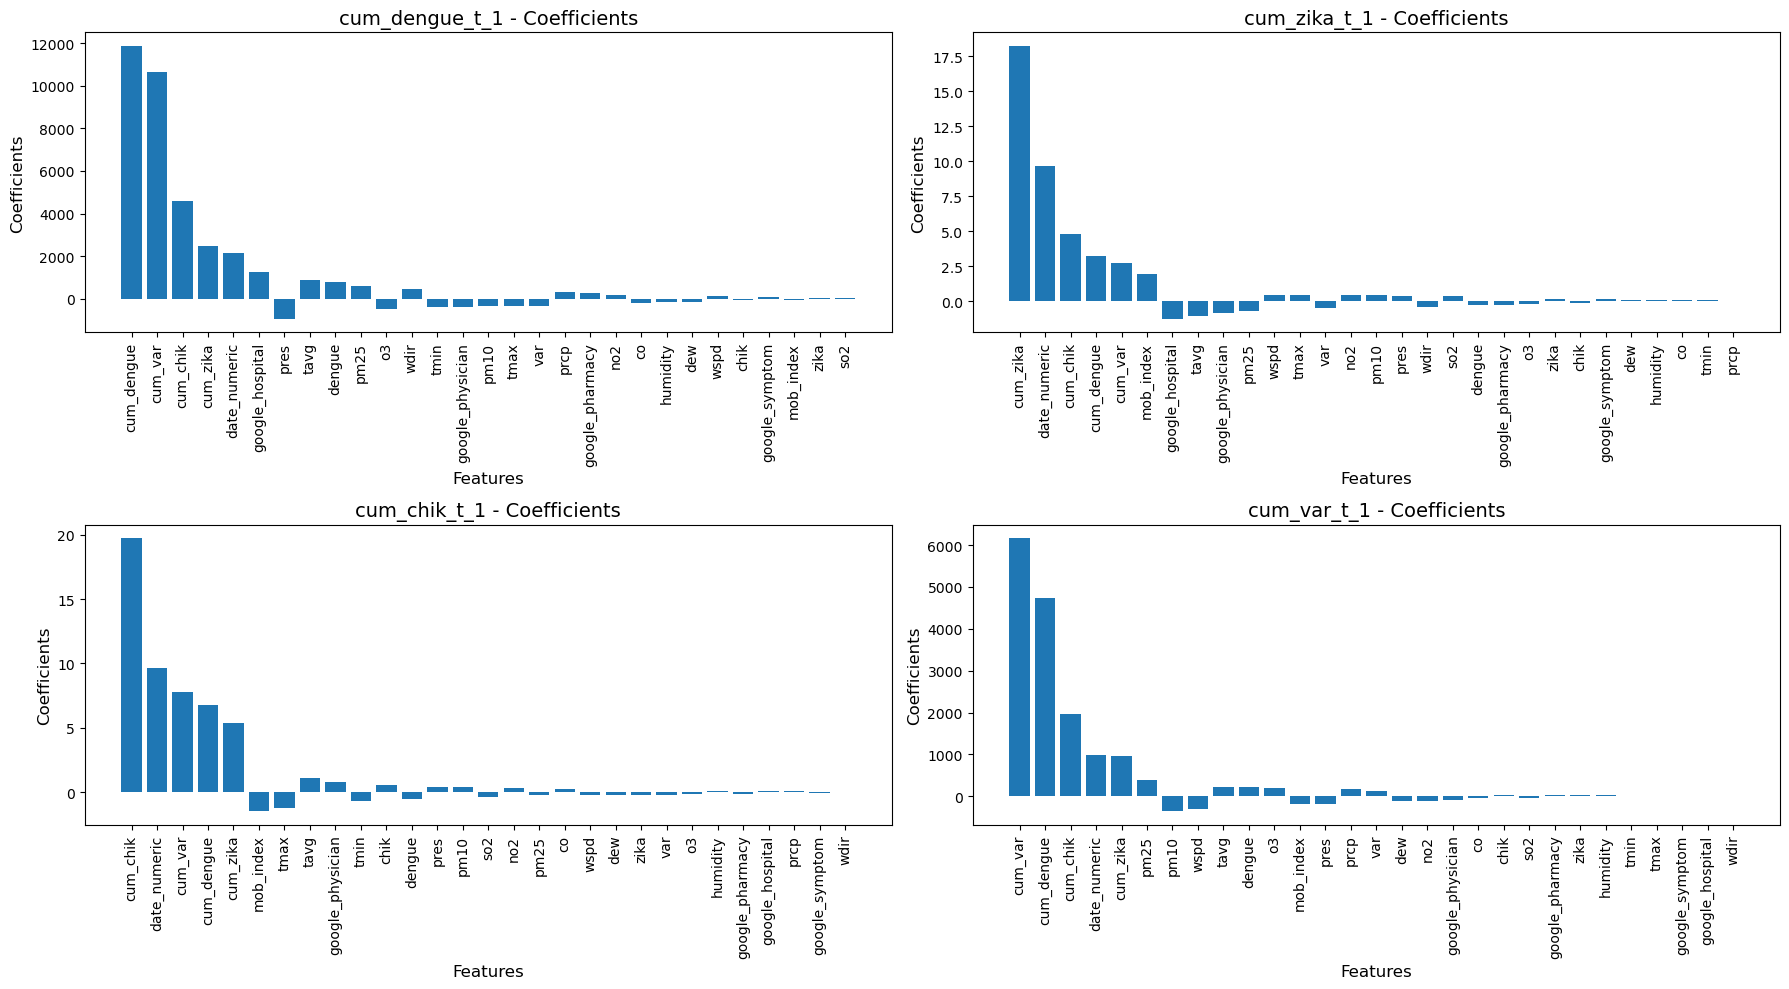

In [42]:
plot_coefficients(df, targets, Ridge())

## ElasticNet

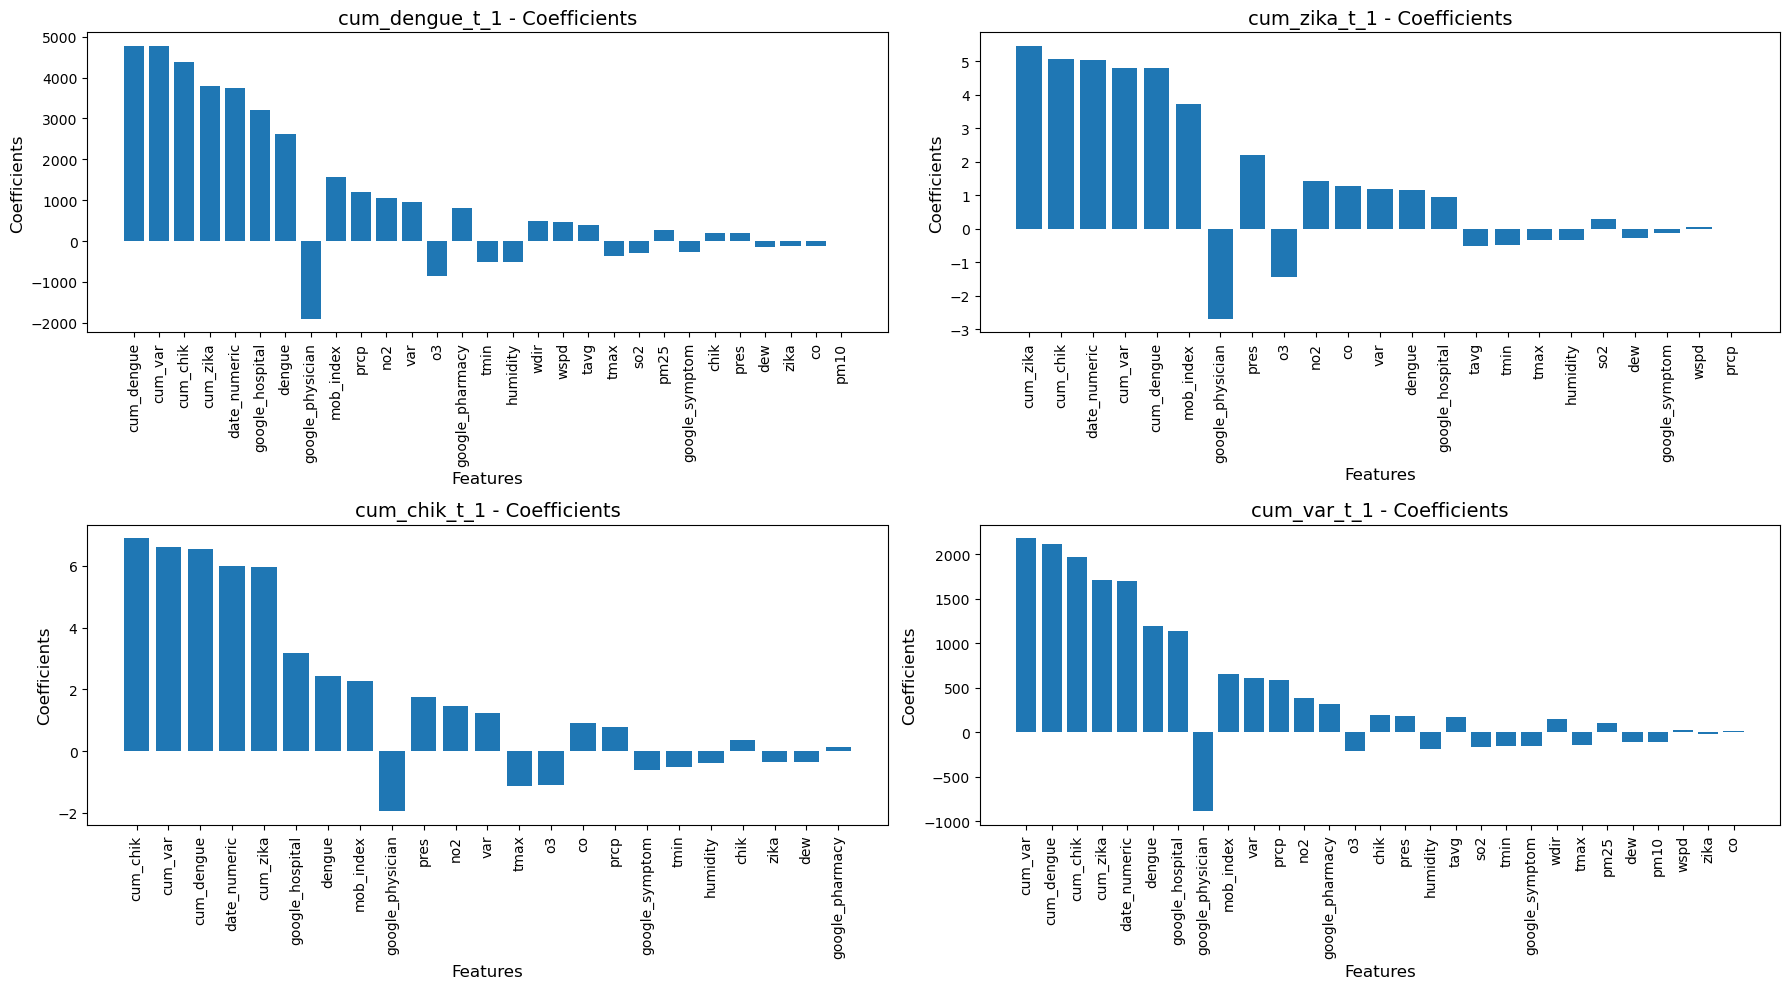

In [43]:
plot_coefficients(df, targets, ElasticNet())

## Random Forest

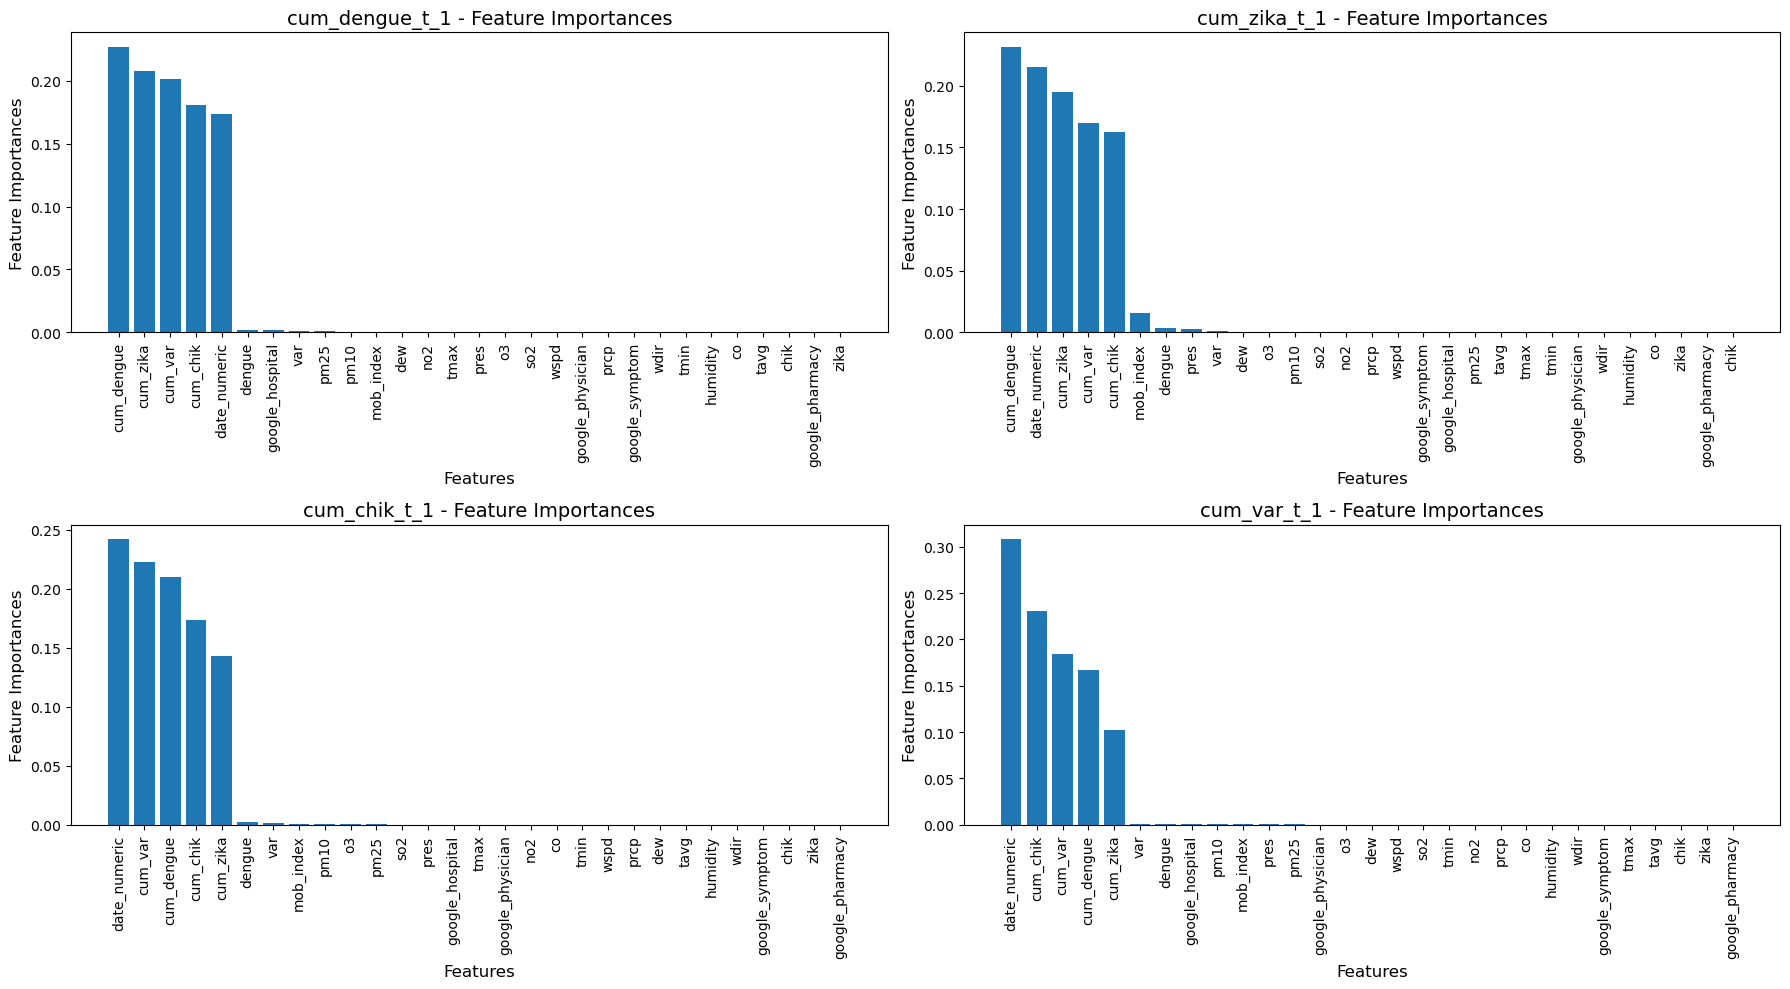

In [44]:
plot_coefficients(df, targets, RandomForestRegressor())

## Gradient Boosting

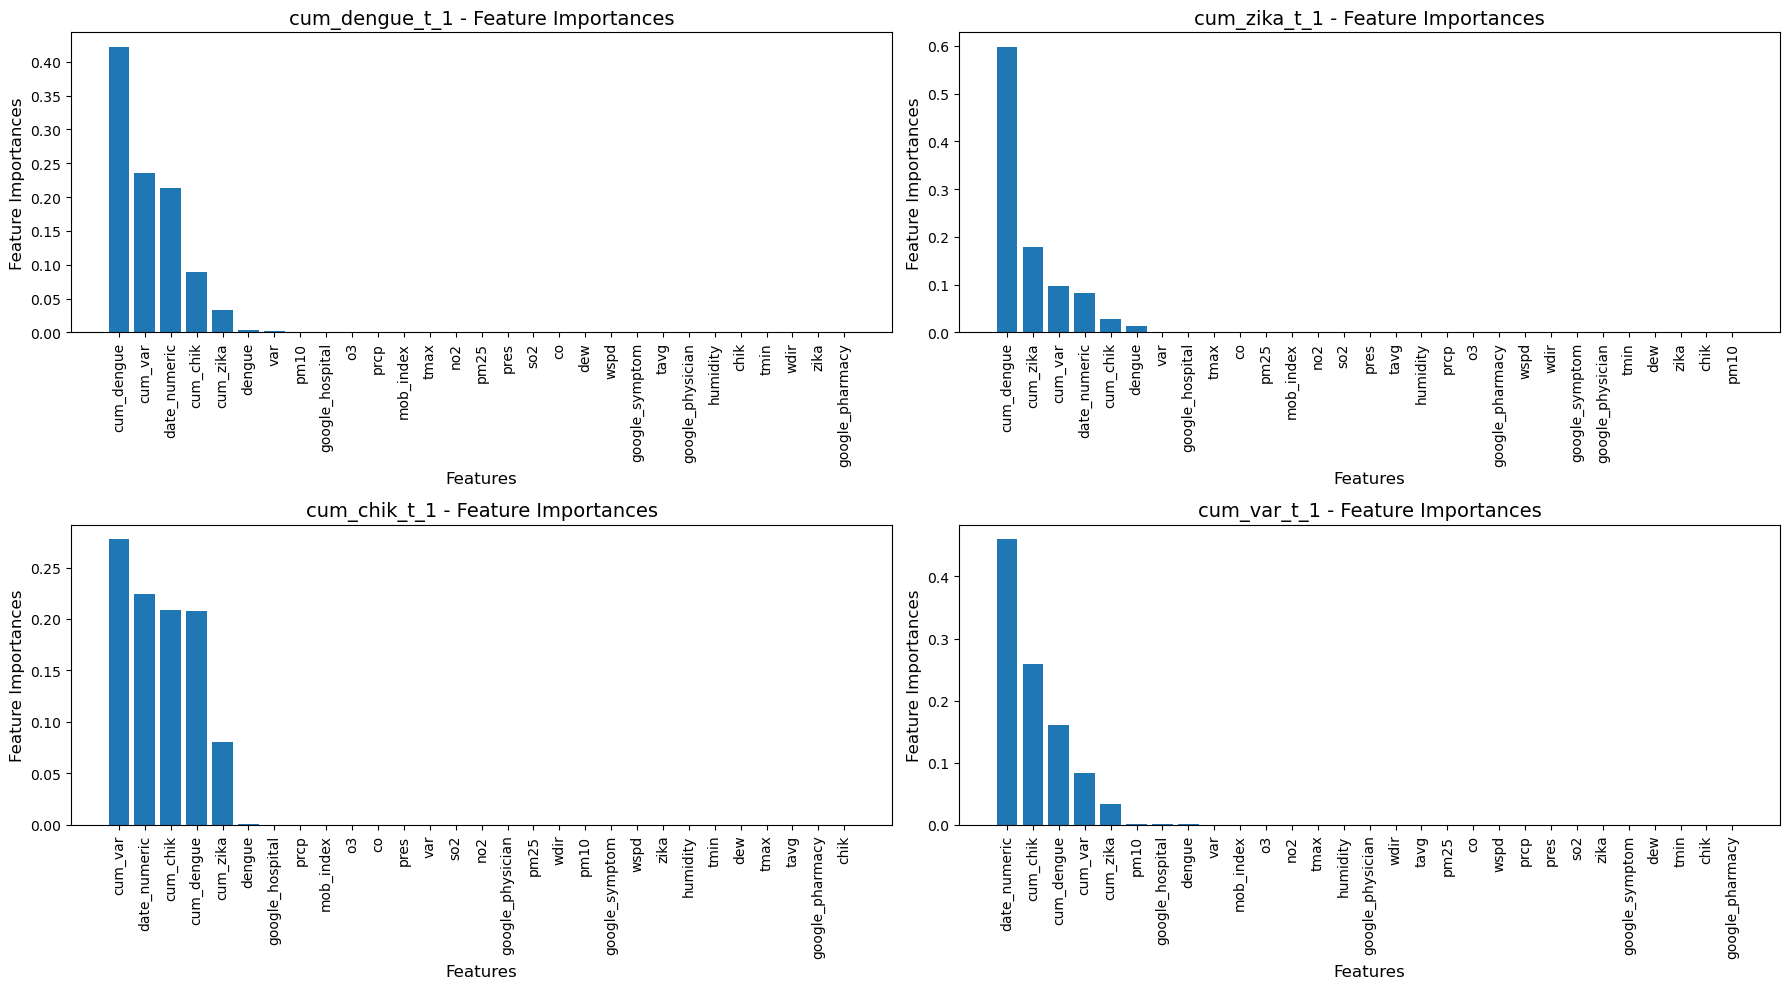

In [45]:
plot_coefficients(df, targets, GradientBoostingRegressor())

They depend almost exclusively on their lagged variables, so modelling as VAR is a good Idea / or any other time series approach as has been done until now

# Feature Engineering

Find the lags that best predict the ```cases_t_1``` for each variable and contrast to each ```country```

In [37]:
def variable_lag_impact(df, targets, max_lag=5):
    results = {}

    for target in targets:

        drop_columns = targets + ['date', 'week']

        variables = [col for col in df.columns if col not in drop_columns]
        corr_dict = {}

        for var in variables:
            lag_corrs = []
            for lag in range(1, max_lag + 1):
                shifted_var = df[var].shift(lag)
                corr = df[target].corr(shifted_var)
                lag_corrs.append(corr)
            corr_dict[var] = lag_corrs

        results[target] = pd.DataFrame(corr_dict, index=[f'lag_{i}' for i in range(1, max_lag + 1)]).T

    return results

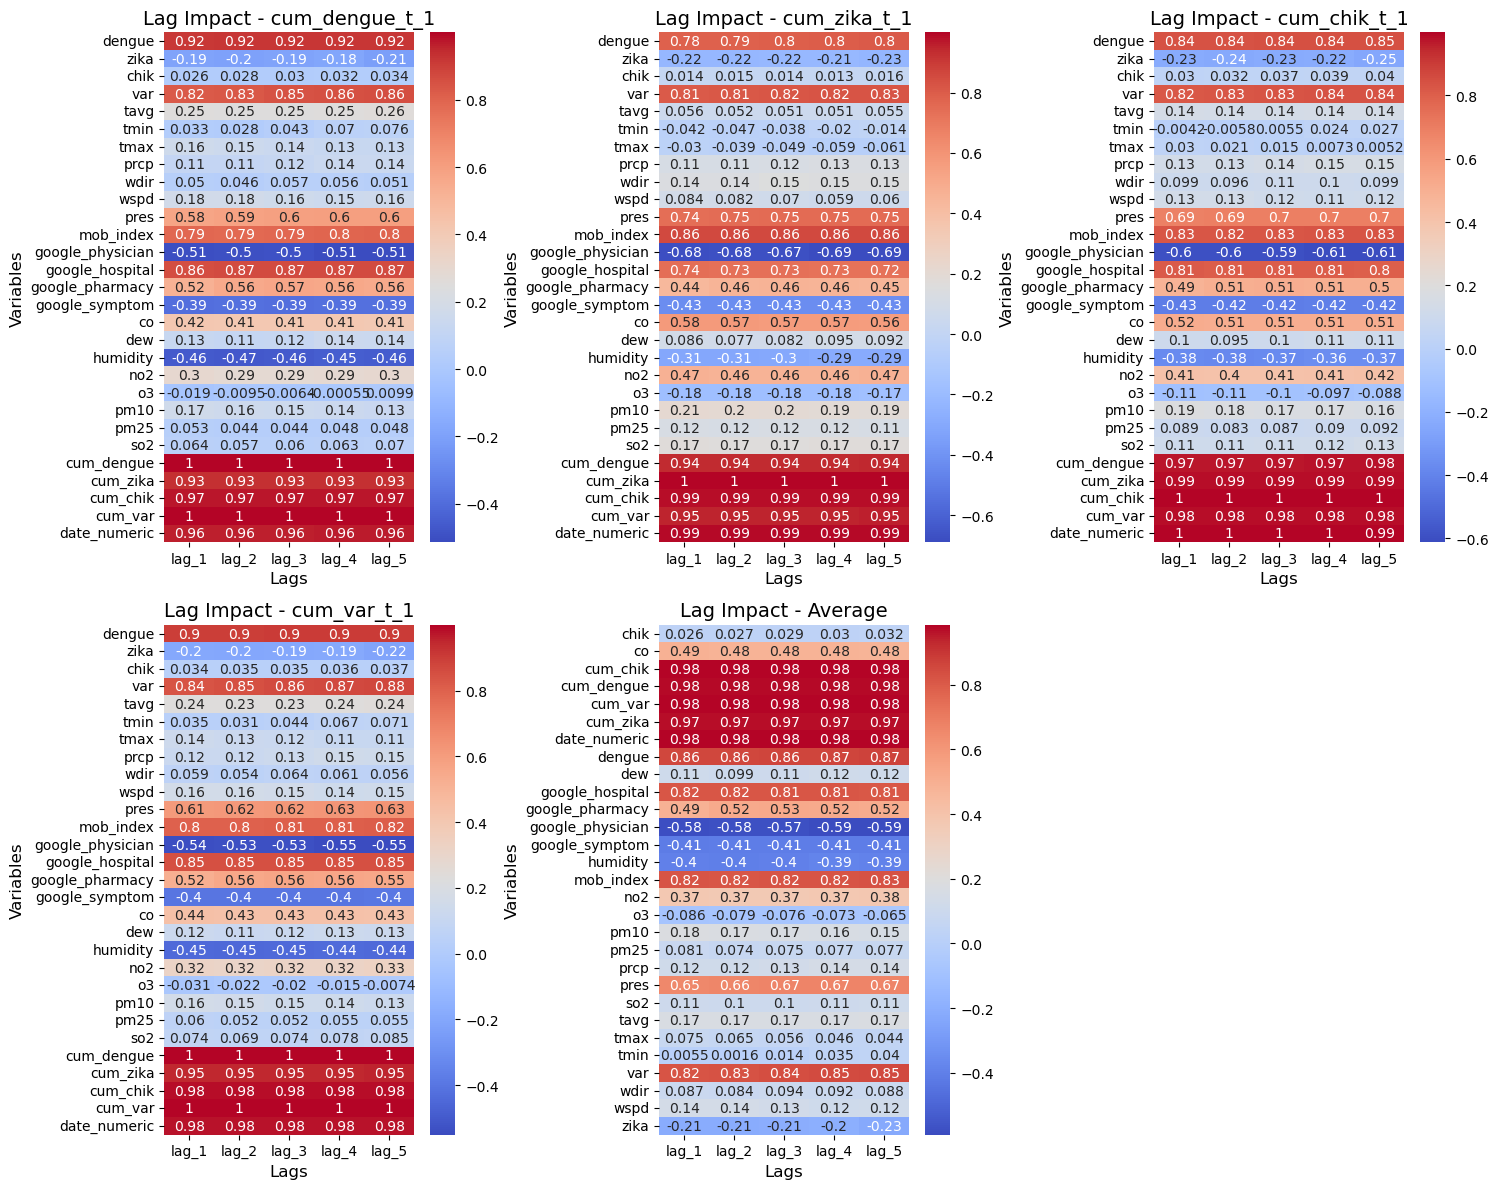

In [38]:
results = variable_lag_impact(df, targets, max_lag=5)

country_names = list(results.keys())
n_cols = (len(country_names) + 2) // 2
fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 12))
axes = axes.flatten()

# Plot country-specific heatmaps
for idx, country_name in enumerate(country_names):
    sns.heatmap(results[country_name], annot=True, cmap='coolwarm', ax=axes[idx])
    axes[idx].set_title(f'Lag Impact - {country_name}', fontsize=14)
    axes[idx].set_xlabel('Lags', fontsize=12)
    axes[idx].set_ylabel('Variables', fontsize=12)

# Compute average table
average_df = pd.concat(results.values()).groupby(level=0).mean()

# Plot average heatmap
sns.heatmap(average_df, annot=True, cmap='coolwarm', ax=axes[len(country_names)])
axes[len(country_names)].set_title('Lag Impact - Average', fontsize=14)
axes[len(country_names)].set_xlabel('Lags', fontsize=12)
axes[len(country_names)].set_ylabel('Variables', fontsize=12)

# Remove empty subplots
for idx in range(len(country_names) + 1, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

Overall is ok to use just one lag for the covariates

# OLS Residuals

In [102]:
df.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'cum_dengue',
       'cum_zika', 'cum_chik', 'cum_var', 'cum_dengue_t_1', 'cum_zika_t_1',
       'cum_chik_t_1', 'cum_var_t_1', 'date_numeric'],
      dtype='object')

In [103]:
df_ols = df.copy()

In [109]:
import statsmodels.api as sm
X = df_ols[[ 'dengue','tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom',  'date_numeric']]
y = df_ols[['cum_dengue_t_1']]
X = sm.add_constant(X)
model = sm.OLS(y,X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         cum_dengue_t_1   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     1133.
Date:                Fri, 28 Mar 2025   Prob (F-statistic):          5.01e-168
Time:                        09:35:53   Log-Likelihood:                -1973.2
No. Observations:                 196   AIC:                             3976.
Df Residuals:                     181   BIC:                             4026.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             4.876e+05   3.24e+05      1.507      0.134   -1.51e+05    1.13e+06
dengue              20.7866      1.432     14.515      0.000      17.961      23.612
tavg              -858.4517   2146.775     -0.400      0.690   -5094.376    3377.473
tmin               225.0173   1061.767      0.212      0.832   -1870.015    2320.050
tmax              2503.3098   1331.864      1.880      0.062    -124.667    5131.287
prcp               614.5800    186.020      3.304      0.001     247.533     981.627
wdir                 6.0026     10.624      0.565      0.573     -14.961      26.966
wspd              -224.0056    696.812     -0.321      0.748   -1598.924    1150.913
pres             -2451.8835    338.119     -7.252      0.000   -3119.045   -1784.722
mob_index          172.3226    156.248      1.103      0.272    -135.979     480.624
google_physician   419.3816    117.494      3.569      0.000     187.548     651.215
google_hospital   1223.4008    262.313      4.664      0.000     705.816    1740.985
google_pharmacy   -676.0447   1005.971     -0.672      0.502   -2660.983    1308.893
google_symptom     146.2145    102.570      1.426      0.156     -56.172     348.601
date_numeric         0.0012   5.57e-05     21.699      0.000       0.001       0.001
==============================================================================
Omnibus:                       10.652   Durbin-Watson:                   0.644
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               10.937
Skew:                          -0.569   Prob(JB):                      0.00422
Kurtosis:                       3.206   Cond. No.                     1.26e+12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.26e+12. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

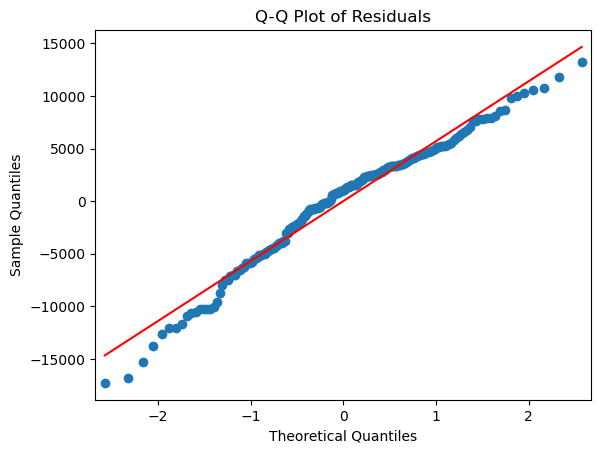

In [110]:
import scipy.stats as stats

# Assuming 'results' is your fitted model
residuals = results.resid

# Create a Q-Q plot
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()


In [111]:

# Shapiro-Wilk Test
shapiro_test = stats.shapiro(residuals)

# Jarque-Bera Test
jarque_bera_test = stats.jarque_bera(residuals)

shapiro_test, jarque_bera_test

(ShapiroResult(statistic=0.9731720286297167, pvalue=0.0008238111469142638),
 SignificanceResult(statistic=10.936767769689743, pvalue=0.00421804349658059))

both have small p values, so there is no normality

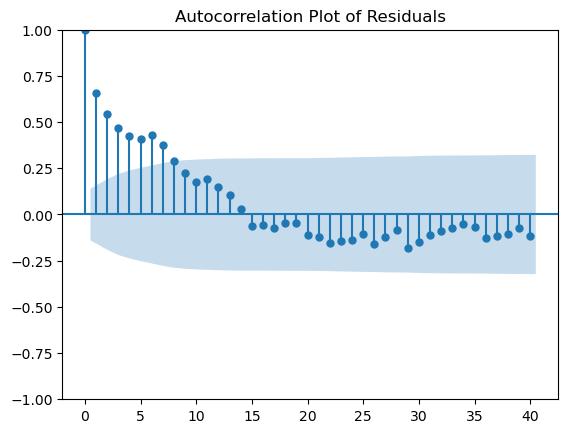

In [112]:
import statsmodels.graphics.tsaplots as tsaplots

# Assuming 'residuals' is the array of residuals from your model
tsaplots.plot_acf(residuals, lags=40)
plt.title('Autocorrelation Plot of Residuals')
plt.show()

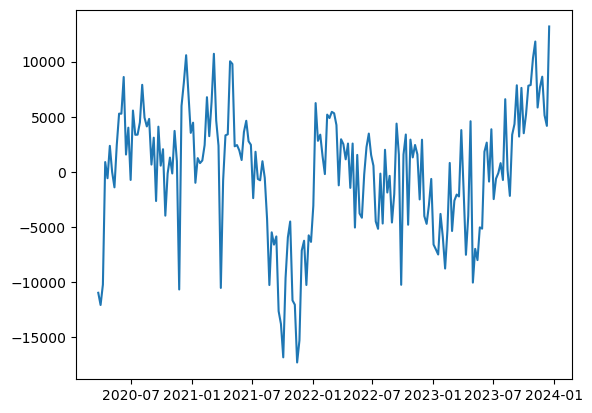

In [113]:
plt.plot(df_ols['date'], residuals)

In [114]:

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the Lasso model
lasso = Lasso(alpha=1.0)  # You can adjust the alpha parameter
lasso.fit(X_scaled, y)

# Get the coefficients
coefficients = lasso.coef_
selected_features = np.where(coefficients != 0)[0]

# Print the selected features and their coefficients
for feature_index in selected_features:
    print(f"Feature: {X.columns[feature_index]}, Coefficient: {coefficients[feature_index]}")


Feature: dengue, Coefficient: 14226.4676925789
Feature: tavg, Coefficient: -556.6877561541631
Feature: tmin, Coefficient: 157.2027011975089
Feature: tmax, Coefficient: 1893.0122335397532
Feature: prcp, Coefficient: 1614.4290518647342
Feature: wdir, Coefficient: 320.1595544988144
Feature: wspd, Coefficient: -218.18662346414303
Feature: pres, Coefficient: -5615.46731314187
Feature: mob_index, Coefficient: 952.0723308343789
Feature: google_physician, Coefficient: 2610.473089075505
Feature: google_hospital, Coefficient: 4845.472624716035
Feature: google_pharmacy, Coefficient: -414.7141410712752
Feature: google_symptom, Coefficient: 736.6500679043577
Feature: date_numeric, Coefficient: 41321.719992130726
